## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


## Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("sales_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving sales_data.csv to sales_data.csv
Dataset loaded successfully!
Shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


## Check Dataset

In [3]:
print("Dataset Information")
print("===================")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Information
Rows: 76000
Columns: 16

Missing Values:
0

Duplicate Rows:
0


## Date Feature Engineering

In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

print("Date features created successfully!")

Date features created successfully!


## Pricing Features

In [5]:
df["Price Difference"] = (
    df["Price"] - df["Competitor Pricing"]
)

df["Price Ratio"] = (
    df["Price"] / df["Competitor Pricing"].replace(0, np.nan)
)

df["Price Ratio"] = df["Price Ratio"].fillna(1)

print("Pricing features created successfully!")

Pricing features created successfully!


## Encode Categorical Features

In [6]:
categorical_columns = [
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Categorical variables encoded!")
print("Final shape:", df.shape)

Categorical variables encoded!
Final shape: (76000, 31)


## Prepare Machine Learning Data

In [7]:
y = df["Demand"]

X = df.drop(
    columns=["Demand", "Date"],
    errors="ignore"
)

X["Store ID"] = X["Store ID"].astype("category").cat.codes
X["Product ID"] = X["Product ID"].astype("category").cat.codes

X = X.astype(int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (76000, 29)
Target shape: (76000,)


## Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (60800, 29)
Testing data: (15200, 29)


## GridSearchCV – Random Forest

In [9]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


## GridSearchCV – Gradient Boosting

In [12]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 5]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Gradient Boosting Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


## Model Evaluation

In [13]:
rf_best = rf_grid.best_estimator_
gb_best = gb_grid.best_estimator_

rf_prediction = rf_best.predict(X_test)
gb_prediction = gb_best.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_prediction)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_prediction))
rf_r2 = r2_score(y_test, rf_prediction)

gb_mae = mean_absolute_error(y_test, gb_prediction)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_prediction))
gb_r2 = r2_score(y_test, gb_prediction)

print("RANDOM FOREST")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

print("\nGRADIENT BOOSTING")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2:", gb_r2)

RANDOM FOREST
MAE: 12.693255978064293
RMSE: 16.90550469165245
R2: 0.8705935928905344

GRADIENT BOOSTING
MAE: 12.252048975759397
RMSE: 16.054034481375886
R2: 0.8833007993882364


## Model Comparison

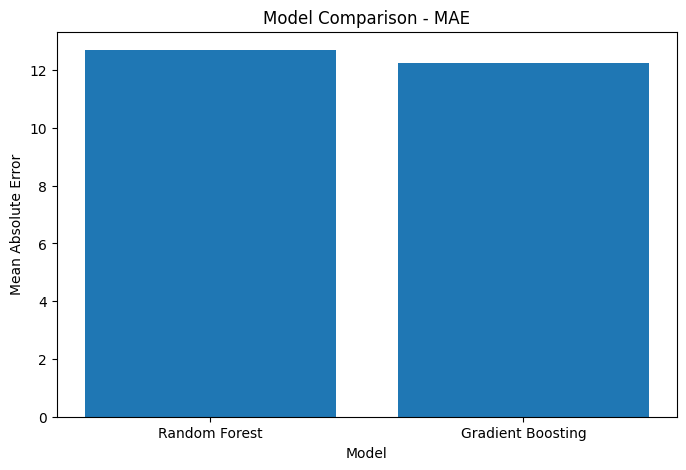

In [14]:
models = ["Random Forest", "Gradient Boosting"]

mae_values = [rf_mae, gb_mae]

plt.figure(figsize=(8, 5))

plt.bar(models, mae_values)

plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.show()

## R² Score Comparison

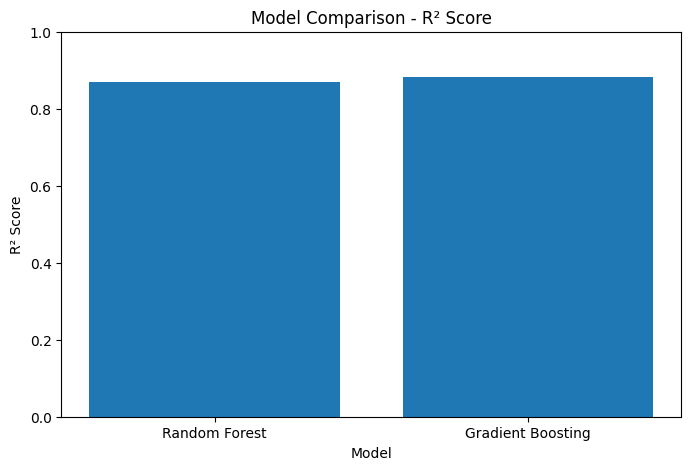

In [15]:
r2_values = [rf_r2, gb_r2]

plt.figure(figsize=(8, 5))

plt.bar(models, r2_values)

plt.title("Model Comparison - R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.ylim(0, 1)

plt.show()

## Actual vs Predicted Demand

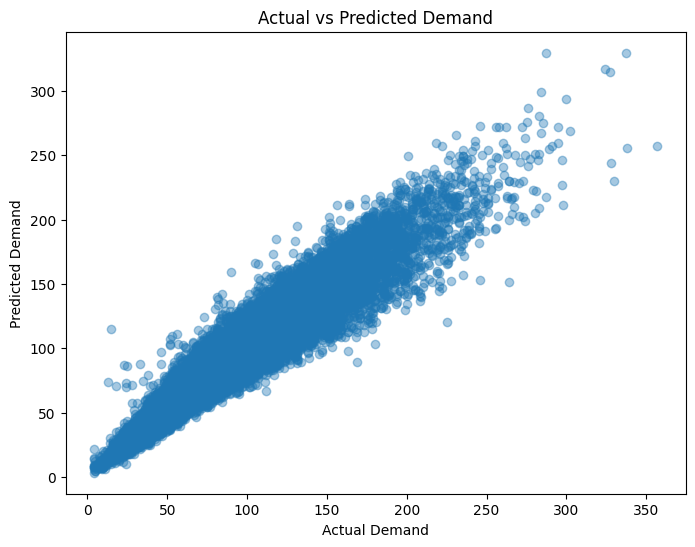

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    gb_prediction,
    alpha=0.4
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")

plt.title("Actual vs Predicted Demand")

plt.show()

## Feature Importance

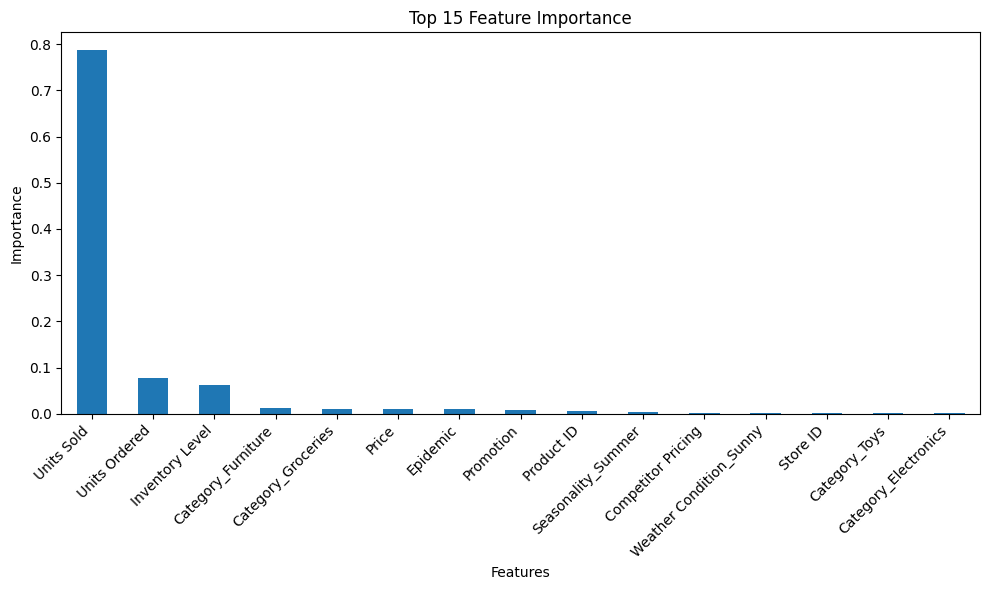

In [17]:
importance = pd.Series(
    gb_best.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

importance.head(15).plot(
    kind="bar"
)

plt.title("Top 15 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Prediction Error Distribution

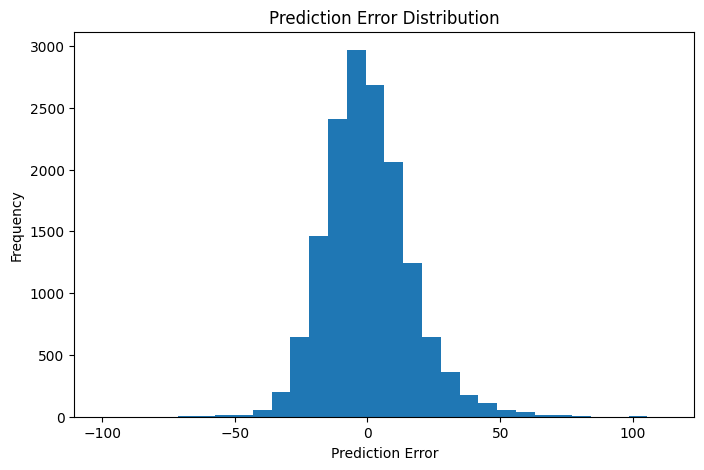

In [19]:
errors = y_test - gb_prediction

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

## Demand vs Price

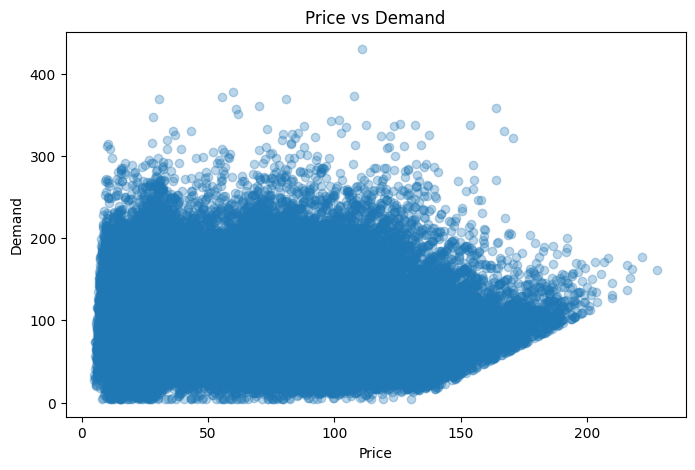

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Price"],
    df["Demand"],
    alpha=0.3
)

plt.xlabel("Price")
plt.ylabel("Demand")

plt.title("Price vs Demand")

plt.show()

## Inventory vs Demand

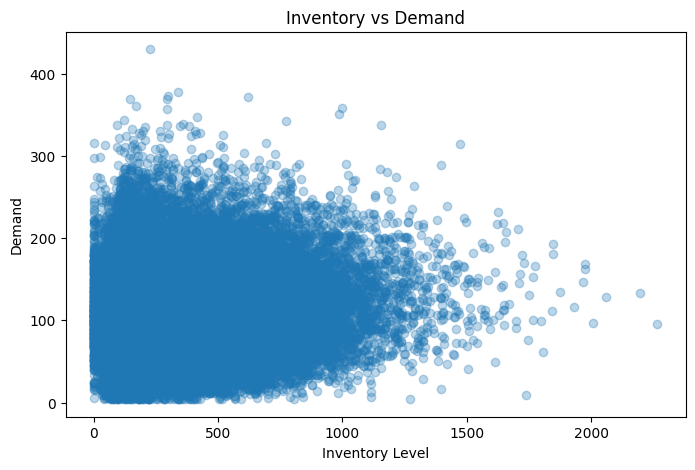

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Inventory Level"],
    df["Demand"],
    alpha=0.3
)

plt.xlabel("Inventory Level")
plt.ylabel("Demand")

plt.title("Inventory vs Demand")

plt.show()

## Pricing Analysis

In [22]:
sample = df.iloc[0]

current_price = sample["Price"]
competitor_price = sample["Competitor Pricing"]
predicted_demand = gb_best.predict(
    X.iloc[[0]]
)[0]
inventory_level = sample["Inventory Level"]

recommended_price = current_price

if predicted_demand > 120 and inventory_level < 200:
    recommended_price = current_price * 1.05

elif predicted_demand < 80 and inventory_level > 300:
    recommended_price = current_price * 0.95

elif current_price > competitor_price:
    recommended_price = competitor_price

recommended_price = round(recommended_price, 2)

print("Current Price:", current_price)
print("Competitor Price:", competitor_price)
print("Predicted Demand:", round(predicted_demand, 2))
print("Inventory Level:", inventory_level)
print("Recommended Price:", recommended_price)

Current Price: 72.72
Competitor Price: 85.73
Predicted Demand: 109.8
Inventory Level: 195
Recommended Price: 72.72


## Price Comparison Graph

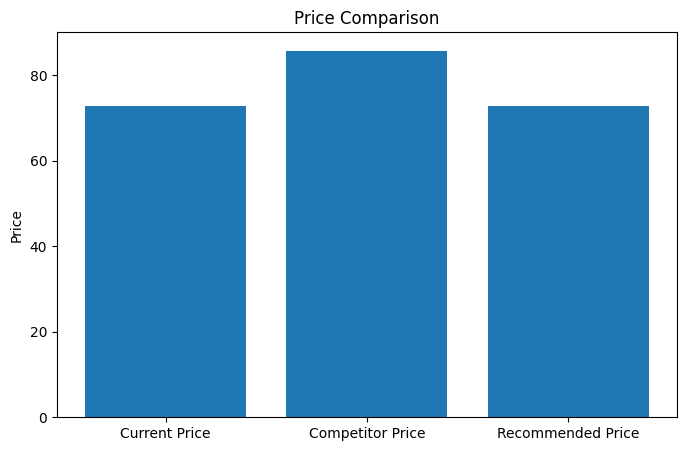

In [23]:
prices = [
    current_price,
    competitor_price,
    recommended_price
]

labels = [
    "Current Price",
    "Competitor Price",
    "Recommended Price"
]

plt.figure(figsize=(8, 5))

plt.bar(labels, prices)

plt.title("Price Comparison")
plt.ylabel("Price")

plt.show()

## Model Performance Table

In [24]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        rf_r2,
        gb_r2
    ]
})

display(results)

,Model,MAE,RMSE,R2 Score
0,Random Forest,12.693256,16.905505,0.870594
1,Gradient Boosting,12.252049,16.054034,0.883301


## Final Best Model

In [25]:
if gb_r2 > rf_r2:
    best_model = gb_best
    best_model_name = "Gradient Boosting"
else:
    best_model = rf_best
    best_model_name = "Random Forest"

print("================================")
print("BEST MODEL")
print("================================")

print("Model:", best_model_name)
print("MAE:", round(min(gb_mae, rf_mae), 4))
print("RMSE:", round(gb_rmse if gb_r2 > rf_r2 else rf_rmse, 4))
print("R² Score:", round(max(gb_r2, rf_r2), 4))

BEST MODEL
Model: Gradient Boosting
MAE: 12.252
RMSE: 16.054
R² Score: 0.8833
